# Build an LLM From Scratch Lab

A transformer-based language model is a long chain of simple ideas that build on one another.

In this notebook we will start with raw text, turn it into tokens, map those tokens into vectors, let attention mix information across positions, stack those computations into transformer blocks, train a tiny language model, and then connect our educational build to GPT-2 Small.

This is a notebook about understanding, not benchmark chasing. We will keep the examples tiny enough to inspect by hand before we scale up to short educational training runs.


## How To Use This Notebook

- Run the notebook from top to bottom the first time so every output stays aligned with the story.
- Pause at the interpretation blocks after each important output. They explain what changed and why the step matters.
- Treat the code as editable lab material. Every function and class is intentionally small enough to inspect.
- Expect the training runs to be educational, not state of the art. They are designed for CPU or a basic Colab session.


In [1]:
import contextlib
import importlib.util
import io
import math
import os
import random
import re
import subprocess
import sys

os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["DISABLE_TELEMETRY"] = "1"

required = {
    "matplotlib": "matplotlib",
    "requests": "requests",
    "torch": "torch",
    "transformers": "transformers",
}
missing = [pkg for pkg, module in required.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import matplotlib.pyplot as plt
import requests
import torch
import torch.nn as nn
import torch.nn.functional as F
import transformers
from huggingface_hub.utils import disable_progress_bars
from transformers import AutoModelForCausalLM, AutoTokenizer

disable_progress_bars()
random.seed(7)
torch.manual_seed(7)
device = "cuda" if torch.cuda.is_available() else "cpu"
plt.style.use("seaborn-v0_8-whitegrid")

print(f"Python: {sys.version.split()[0]}")
print(f"PyTorch: {torch.__version__}")
print(f"Transformers: {transformers.__version__}")
print(f"Device: {device}")


Python: 3.13.9
PyTorch: 2.10.0+cpu
Transformers: 5.3.0
Device: cpu


## Phase 0. Roadmap

We will follow the same learning arc that a language model follows computationally:

1. **Text to tokens**: make discrete symbols that a model can index.
2. **Tokens to embeddings**: replace ids with dense vectors.
3. **Positional information**: inject token order.
4. **Single-head attention**: compute which earlier tokens matter for the current token.
5. **Multi-head attention**: let several attention patterns coexist.
6. **MLP and residual stream**: refine and preserve information.
7. **Transformer language model**: compose the full block stack and produce logits.
8. **Autoregressive generation**: predict one next token at a time.
9. **Stage A training**: learn on tiny synthetic text we can fully understand.
10. **Stage B training**: move to a tiny Project Gutenberg corpus.
11. **GPT-2 Small comparison**: connect the educational build to a real pretrained model.


In [2]:
def rounded(tensor, decimals=3):
    """Detach a tensor, move it to CPU, and round it for readable notebook printing."""
    factor = 10 ** decimals
    return torch.round(tensor.detach().cpu() * factor) / factor


def plot_matrix(matrix, row_labels, col_labels, title, cmap="Blues"):
    """Render a small annotated heatmap for masks, scores, or attention weights."""
    data = matrix.detach().cpu()
    fig, ax = plt.subplots(figsize=(4.8, 4.0))
    image = ax.imshow(data, cmap=cmap)
    ax.set_xticks(range(len(col_labels)), labels=col_labels, rotation=45, ha="right")
    ax.set_yticks(range(len(row_labels)), labels=row_labels)
    ax.set_title(title)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            ax.text(j, i, f"{data[i, j]:.2f}", ha="center", va="center", fontsize=9)
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


def plot_loss_curves(history, title):
    """Plot train/validation loss so we can see whether learning is actually happening."""
    fig, ax = plt.subplots(figsize=(6.4, 3.6))
    ax.plot(history["steps"], history["train"], marker="o", label="train loss")
    ax.plot(history["steps"], history["val"], marker="s", label="val loss")
    ax.set_title(title)
    ax.set_xlabel("Step")
    ax.set_ylabel("Cross-entropy loss")
    ax.legend()
    plt.tight_layout()
    plt.show()


def count_parameters(model):
    """Return the total number of trainable parameters in a model."""
    return sum(parameter.numel() for parameter in model.parameters())


print("Display helpers are ready.")


Display helpers are ready.


## Whole-Model Architecture At A Glance

Before we zoom into individual components, it helps to see the entire autoregressive pipeline as one system.

The diagram below shows the flow we will build throughout the notebook, including the repeated transformer block structure and the final next-token prediction step.


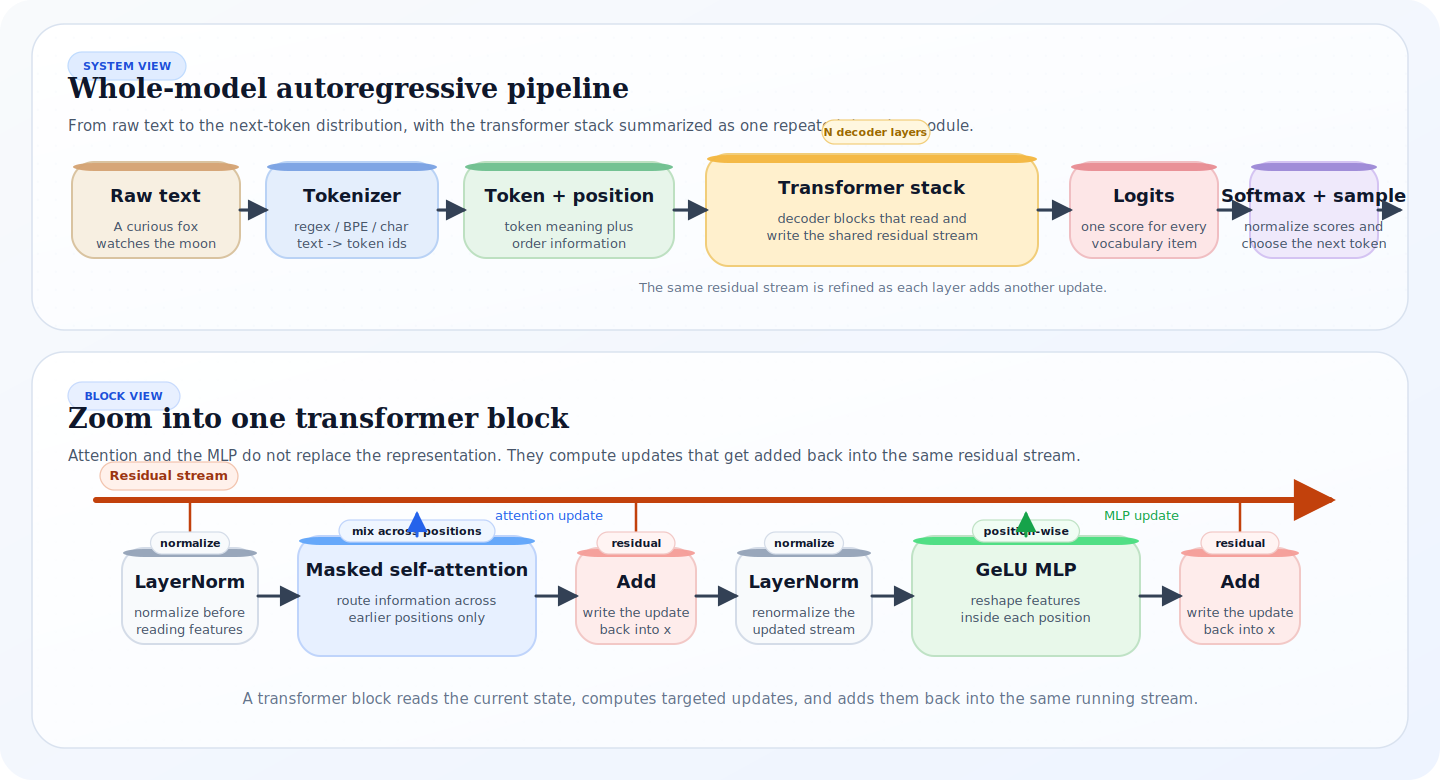

In [3]:
from html import escape
from IPython.display import SVG, display


def svg_multiline(
    x,
    y,
    lines,
    *,
    font_size=14,
    line_height=18,
    fill="#475569",
    weight=400,
    anchor="middle",
    letter_spacing=None,
    css_class=None,
):
    """Render a multi-line SVG text block with consistent spacing."""
    extra = f' letter-spacing="{letter_spacing}"' if letter_spacing is not None else ""
    class_attr = f' class="{css_class}"' if css_class is not None else ""
    spans = []
    for i, line in enumerate(lines):
        dy = 0 if i == 0 else line_height
        spans.append(f'<tspan x="{x}" dy="{dy}">{escape(line)}</tspan>')
    return (
        f'<text x="{x}" y="{y}" text-anchor="{anchor}" font-size="{font_size}" '
        f'font-weight="{weight}" fill="{fill}"{extra}{class_attr}>{"".join(spans)}</text>'
    )


def svg_pill(x, y, width, height, label, *, fill, stroke, text_fill="#0f172a", font_size=12, weight=600):
    """Render a compact rounded label chip."""
    return "".join(
        [
            f'<rect x="{x}" y="{y}" width="{width}" height="{height}" rx="{height/2}" fill="{fill}" stroke="{stroke}" stroke-width="1.25"/>',
            f'<text x="{x + width/2}" y="{y + height/2 + 4}" text-anchor="middle" font-size="{font_size}" font-weight="{weight}" fill="{text_fill}">{escape(label)}</text>',
        ]
    )


def svg_box(x, y, width, height, title, subtitle_lines, *, fill, stroke, accent, chip=None, chip_fill="#ffffff", chip_stroke="#cbd5e1"):
    """Render one rounded stage box with a colored accent bar and optional chip."""
    parts = [
        '<g filter="url(#softShadow)">',
        f'<rect x="{x}" y="{y}" width="{width}" height="{height}" rx="22" fill="{fill}" stroke="{stroke}" stroke-width="2"/>',
        f'<rect x="{x + 1}" y="{y + 1}" width="{width - 2}" height="8" rx="21" fill="{accent}" opacity="0.95"/>',
        '</g>',
        svg_multiline(x + width / 2, y + 40, [title], font_size=18, fill="#0f172a", weight=700),
        svg_multiline(x + width / 2, y + 69, subtitle_lines, font_size=13, line_height=17, fill="#475569"),
    ]
    if chip:
        chip_width = max(78, 16 + 7 * len(chip))
        parts.append(
            svg_pill(
                x + width / 2 - chip_width / 2,
                y - 16,
                chip_width,
                22,
                chip,
                fill=chip_fill,
                stroke=chip_stroke,
                font_size=11,
            )
        )
    return "".join(parts)


def svg_arrow(x1, y1, x2, y2, *, color="#334155", width=3, marker="arrow-slate", dashed=False):
    """Draw a straight SVG arrow with an optional dashed stroke."""
    dash = ' stroke-dasharray="8 7"' if dashed else ""
    return (
        f'<line x1="{x1}" y1="{y1}" x2="{x2}" y2="{y2}" stroke="{color}" stroke-width="{width}" '
        f'stroke-linecap="round" marker-end="url(#{marker})"{dash}/>'
    )


svg = f"""
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 1440 780" width="1440" height="780" role="img" aria-label="A polished overview of the transformer language-model pipeline and one transformer block.">
  <defs>
    <style>
      text {{ font-family: Inter, Segoe UI, Arial, sans-serif; }}
      .display-title {{ font-family: Georgia, Times New Roman, serif; }}
    </style>
    <linearGradient id="pageBg" x1="0%" y1="0%" x2="100%" y2="100%">
      <stop offset="0%" stop-color="#f8fafc"/>
      <stop offset="100%" stop-color="#eef4ff"/>
    </linearGradient>
    <linearGradient id="panelBg" x1="0%" y1="0%" x2="100%" y2="100%">
      <stop offset="0%" stop-color="#ffffff"/>
      <stop offset="100%" stop-color="#f8fbff"/>
    </linearGradient>
    <filter id="softShadow" x="-10%" y="-10%" width="120%" height="120%">
      <feDropShadow dx="0" dy="12" stdDeviation="14" flood-color="#0f172a" flood-opacity="0.10"/>
    </filter>
    <pattern id="dotGrid" width="18" height="18" patternUnits="userSpaceOnUse">
      <circle cx="1.8" cy="1.8" r="1.2" fill="#dbe4f0" opacity="0.65"/>
    </pattern>
    <marker id="arrow-slate" viewBox="0 0 10 10" refX="8.6" refY="5" markerWidth="7" markerHeight="7" orient="auto-start-reverse">
      <path d="M 0 0 L 10 5 L 0 10 z" fill="#334155"/>
    </marker>
    <marker id="arrow-blue" viewBox="0 0 10 10" refX="8.6" refY="5" markerWidth="7" markerHeight="7" orient="auto-start-reverse">
      <path d="M 0 0 L 10 5 L 0 10 z" fill="#2563eb"/>
    </marker>
    <marker id="arrow-green" viewBox="0 0 10 10" refX="8.6" refY="5" markerWidth="7" markerHeight="7" orient="auto-start-reverse">
      <path d="M 0 0 L 10 5 L 0 10 z" fill="#16a34a"/>
    </marker>
    <marker id="arrow-orange" viewBox="0 0 10 10" refX="8.6" refY="5" markerWidth="7" markerHeight="7" orient="auto-start-reverse">
      <path d="M 0 0 L 10 5 L 0 10 z" fill="#c2410c"/>
    </marker>
  </defs>

  <rect x="0" y="0" width="1440" height="780" rx="32" fill="url(#pageBg)"/>

  <g filter="url(#softShadow)">
    <rect x="32" y="24" width="1376" height="306" rx="32" fill="url(#panelBg)" stroke="#d9e2ef" stroke-width="1.5"/>
    <rect x="32" y="352" width="1376" height="396" rx="32" fill="url(#panelBg)" stroke="#d9e2ef" stroke-width="1.5"/>
  </g>
  <rect x="32" y="24" width="1376" height="306" rx="32" fill="url(#dotGrid)" opacity="0.18"/>
  <rect x="32" y="352" width="1376" height="396" rx="32" fill="url(#dotGrid)" opacity="0.18"/>

  {svg_pill(68, 52, 118, 28, 'SYSTEM VIEW', fill='#e0ecff', stroke='#bfdbfe', text_fill='#1d4ed8', font_size=11)}
  {svg_multiline(68, 98, ['Whole-model autoregressive pipeline'], font_size=27, fill='#0f172a', weight=800, anchor='start', css_class='display-title')}
  {svg_multiline(68, 131, ['From raw text to the next-token distribution, with the transformer stack summarized as one repeated decoder module.'], font_size=15, line_height=20, fill='#475569', anchor='start')}

  <line x1="90" y1="210" x2="1350" y2="210" stroke="#cbd5e1" stroke-width="4" stroke-linecap="round" opacity="0.6"/>

  {svg_box(72, 162, 168, 96, 'Raw text', ['A curious fox', 'watches the moon'], fill='#f7efe1', stroke='#d9c3a0', accent='#d4a373')}
  {svg_box(266, 162, 172, 96, 'Tokenizer', ['regex / BPE / char', 'text -> token ids'], fill='#e4eefc', stroke='#b9d2f5', accent='#7aa2e3')}
  {svg_box(464, 162, 210, 96, 'Token + position', ['token meaning plus', 'order information'], fill='#e7f5ea', stroke='#bde0c1', accent='#6fbf8f')}
  {svg_box(706, 154, 332, 112, 'Transformer stack', ['decoder blocks that read and', 'write the shared residual stream'], fill='#fff0cd', stroke='#f1cd79', accent='#f4b73f')}
  {svg_box(1070, 162, 148, 96, 'Logits', ['one score for every', 'vocabulary item'], fill='#fde6e7', stroke='#f0bec2', accent='#e88d93')}
  {svg_box(1250, 162, 128, 96, 'Softmax + sample', ['normalize scores and', 'choose the next token'], fill='#efe9fb', stroke='#d4c3f2', accent='#9d89d6')}

  {svg_pill(822, 120, 108, 24, 'N decoder layers', fill='#fff7df', stroke='#f1cd79', text_fill='#9a6700', font_size=11)}
  {svg_multiline(872, 292, ['The same residual stream is refined as each layer adds another update.'], font_size=13, line_height=17, fill='#64748b', anchor='middle')}

  {svg_arrow(240, 210, 266, 210)}
  {svg_arrow(438, 210, 464, 210)}
  {svg_arrow(674, 210, 706, 210)}
  {svg_arrow(1038, 210, 1070, 210)}
  {svg_arrow(1218, 210, 1250, 210)}
  {svg_arrow(1378, 210, 1400, 210)}

  {svg_pill(68, 382, 112, 28, 'BLOCK VIEW', fill='#e8f0ff', stroke='#c7dafd', text_fill='#1d4ed8', font_size=11)}
  {svg_multiline(68, 428, ['Zoom into one transformer block'], font_size=27, fill='#0f172a', weight=800, anchor='start', css_class='display-title')}
  {svg_multiline(68, 461, ['Attention and the MLP do not replace the representation. They compute updates that get added back into the same residual stream.'], font_size=15, line_height=20, fill='#475569', anchor='start')}

  <line x1="96" y1="500" x2="1288" y2="500" stroke="#c2410c" stroke-width="6" stroke-linecap="round"/>
  {svg_arrow(1288, 500, 1330, 500, color='#c2410c', width=6, marker='arrow-orange')}
  {svg_pill(100, 462, 138, 28, 'Residual stream', fill='#fff1eb', stroke='#f1c3ad', text_fill='#9a3412', font_size=13)}

  <line x1="190" y1="500" x2="190" y2="536" stroke="#c2410c" stroke-width="2.5"/>
  <line x1="636" y1="500" x2="636" y2="536" stroke="#c2410c" stroke-width="2.5"/>
  <line x1="1240" y1="500" x2="1240" y2="536" stroke="#c2410c" stroke-width="2.5"/>

  {svg_box(122, 548, 136, 96, 'LayerNorm', ['normalize before', 'reading features'], fill='#f8fafc', stroke='#d4dce8', accent='#94a3b8', chip='normalize', chip_fill='#f8fafc', chip_stroke='#d4dce8')}
  {svg_box(298, 536, 238, 120, 'Masked self-attention', ['route information across', 'earlier positions only'], fill='#e7f0ff', stroke='#bfd4fb', accent='#60a5fa', chip='mix across positions', chip_fill='#eff6ff', chip_stroke='#bfd4fb')}
  {svg_box(576, 548, 120, 96, 'Add', ['write the update', 'back into x'], fill='#feeceb', stroke='#f2c8c6', accent='#f59e99', chip='residual', chip_fill='#fff4f3', chip_stroke='#f2c8c6')}
  {svg_box(736, 548, 136, 96, 'LayerNorm', ['renormalize the', 'updated stream'], fill='#f8fafc', stroke='#d4dce8', accent='#94a3b8', chip='normalize', chip_fill='#f8fafc', chip_stroke='#d4dce8')}
  {svg_box(912, 536, 228, 120, 'GeLU MLP', ['reshape features', 'inside each position'], fill='#e8f8ea', stroke='#bfe2c5', accent='#4ade80', chip='position-wise', chip_fill='#f0fdf4', chip_stroke='#bfe2c5')}
  {svg_box(1180, 548, 120, 96, 'Add', ['write the update', 'back into x'], fill='#feeceb', stroke='#f2c8c6', accent='#f59e99', chip='residual', chip_fill='#fff4f3', chip_stroke='#f2c8c6')}

  {svg_arrow(258, 596, 298, 596)}
  {svg_arrow(536, 596, 576, 596)}
  {svg_arrow(696, 596, 736, 596)}
  {svg_arrow(872, 596, 912, 596)}
  {svg_arrow(1140, 596, 1180, 596)}

  {svg_arrow(417, 536, 417, 514, color='#2563eb', width=3, marker='arrow-blue')}
  {svg_arrow(1026, 536, 1026, 514, color='#16a34a', width=3, marker='arrow-green')}
  {svg_multiline(495, 520, ['attention update'], font_size=13, fill='#2563eb', anchor='start')}
  {svg_multiline(1104, 520, ['MLP update'], font_size=13, fill='#16a34a', anchor='start')}

  {svg_multiline(720, 704, ['A transformer block reads the current state, computes targeted updates, and adds them back into the same running stream.'], font_size=15, fill='#64748b', anchor='middle')}
</svg>
"""

display(SVG(svg))


### What to notice

The figure separates two scales of explanation: the top panel shows the full left-to-right prediction loop, while the bottom panel slows down inside a single transformer block.

### What this step contributes

The orange line in the lower panel names an idea we will keep returning to: the model carries one running hidden state forward through the network, and each sublayer writes an update back into that same stream.

### Why it matters

That running hidden state is what people mean by the **residual stream**. The add-back paths are the **residual connections**. Naming them early matters because almost every later transformer idea is easiest to understand as an operation on that shared stream rather than as a brand-new representation invented at every layer.


## Phase 1. Text To Tokens

The model cannot work directly with raw strings. It needs a discrete vocabulary.

We start with a tiny regex-based word tokenizer because it makes the conversion visible:

$$
\text{token ids} = \text{vocab lookup}(\text{Tokenizer}(\text{text}))
$$

Later we will intentionally switch to a character-level tokenizer for the scratch model. That simplification keeps training fast and makes every prediction easy to inspect.


In [4]:
sample_text = "The capital of Kenya is Nairobi."
word_pattern = re.compile(r"[A-Za-z']+|[.,!?;:]")


def word_tokenize(text):
    return word_pattern.findall(text)


def word_detokenize(tokens):
    pieces = []
    for token in tokens:
        if token in ".,!?;:":
            pieces.append(token)
        elif not pieces:
            pieces.append(token)
        else:
            pieces.append(" " + token)
    return "".join(pieces)


word_tokens = word_tokenize(sample_text)
word_stoi = {token: idx for idx, token in enumerate(sorted(set(word_tokens)))}
word_itos = {idx: token for token, idx in word_stoi.items()}


def word_encode(text):
    return [word_stoi[token] for token in word_tokenize(text)]


def word_decode(ids):
    return word_detokenize([word_itos[idx] for idx in ids])


encoded_words = word_encode(sample_text)
print("Sample text:", sample_text)
print("Word tokens:", word_tokens)
print("Word vocabulary:", word_stoi)
print("Encoded ids:", encoded_words)
print("Decoded text:", word_decode(encoded_words))


Sample text: The capital of Kenya is Nairobi.
Word tokens: ['The', 'capital', 'of', 'Kenya', 'is', 'Nairobi', '.']
Word vocabulary: {'.': 0, 'Kenya': 1, 'Nairobi': 2, 'The': 3, 'capital': 4, 'is': 5, 'of': 6}
Encoded ids: [3, 4, 6, 1, 5, 2, 0]
Decoded text: The capital of Kenya is Nairobi.


### What to notice

A single sentence has been broken into a short list of word and punctuation tokens, then mapped into integer ids.

### What this step contributes

We moved from continuous text to a finite vocabulary lookup. The tokenizer decided where token boundaries live, and the vocabulary assigned each token a stable integer.

### Why it matters

Everything that follows depends on this discrete interface. Embeddings, attention, logits, and loss all operate on token ids rather than raw text.


### Why Switch To Characters For The Scratch Model?

A word-level tokenizer is good for intuition, but it becomes awkward for a tiny educational training run because every new word can become an out-of-vocabulary problem.

A character-level tokenizer is slower for real models but perfect for a small lab:

- every visible symbol becomes learnable
- vocabulary size stays tiny
- decoding is easy to inspect
- we can train quickly on CPU or in Colab


In [5]:
toy_sentences = [
    "The capital of Kenya is Nairobi.",
    "The capital of Italy is Rome.",
    "The capital of Japan is Tokyo.",
    "The capital of Brazil is Brasilia.",
    "The capital of Egypt is Cairo.",
    "The capital of India is New Delhi.",
    "2 plus 2 equals 4.",
    "3 plus 3 equals 6.",
    "4 plus 4 equals 8.",
    "The red bird sings at dawn.",
    "The blue bird sings at dusk.",
    "A small fox sees the moon.",
    "A small fox sees the sun.",
]
toy_preview_text = "\n".join(toy_sentences)


def build_char_tokenizer(text):
    chars = sorted(set(text))
    stoi = {ch: idx for idx, ch in enumerate(chars)}
    itos = {idx: ch for ch, idx in stoi.items()}

    def encode(text_fragment):
        return [stoi[ch] for ch in text_fragment]

    def decode(ids):
        return "".join(itos[idx] for idx in ids)

    return chars, stoi, itos, encode, decode


preview_chars, preview_stoi, preview_itos, preview_encode, preview_decode = build_char_tokenizer(toy_preview_text)
preview_text = "The capital of Japan is Tokyo."
preview_ids = preview_encode(preview_text)

print("Character vocabulary size:", len(preview_chars))
print("First 20 characters in the vocabulary:", preview_chars[:20])
print("Preview text:", preview_text)
print("Encoded ids (first 20):", preview_ids[:20])
print("Decoded text:", preview_decode(preview_ids))


Character vocabulary size: 43
First 20 characters in the vocabulary: ['\n', ' ', '.', '2', '3', '4', '6', '8', 'A', 'B', 'C', 'D', 'E', 'I', 'J', 'K', 'N', 'R', 'T', 'a']
Preview text: The capital of Japan is Tokyo.
Encoded ids (first 20): [18, 26, 23, 1, 21, 19, 33, 27, 37, 19, 29, 1, 32, 24, 1, 14, 19, 33, 19, 31]
Decoded text: The capital of Japan is Tokyo.


### What to notice

The same text interface has been rebuilt at character level, so every letter, space, punctuation mark, and newline gets its own id.

### What this step contributes

We shrank the vocabulary dramatically and made tokenization lossless for this tiny corpus. The encoder and decoder now operate character by character.

### Why it matters

This simplification makes the later training runs practical and easy to debug. Every next-token prediction becomes a next-character prediction we can read directly.


## Phase 2. Tokens To Embeddings

Token ids are discrete labels, but transformer blocks operate on vectors. An embedding table performs a learned lookup:

$$
\mathbf{x}_i = E[\mathrm{token}_i]
$$

Each row of the embedding matrix is a trainable vector. Looking up token ids pulls out the rows associated with the current sequence.

In this notebook we start with an embedding width of just **6** so the vectors still fit on the page. That is purely an educational choice. Real language models use much wider representations because the same vector space usually also serves as the model's residual stream.


In [6]:
embedding_dim = 6  # Deliberately tiny so every coordinate still fits comfortably on the page.
token_embedding = nn.Embedding(len(preview_chars), embedding_dim)
lookup_text = "Rome."
lookup_ids = torch.tensor(preview_encode(lookup_text), dtype=torch.long)
lookup_vectors = token_embedding(lookup_ids)

print("Lookup text:", lookup_text)
print("Token ids:", lookup_ids.tolist())
print("Embedding table shape:", tuple(token_embedding.weight.shape))
print("Lookup result shape:", tuple(lookup_vectors.shape))
print("Embedding vectors:")
print(rounded(lookup_vectors))


Lookup text: Rome.
Token ids: [17, 32, 30, 23, 2]
Embedding table shape: (43, 6)
Lookup result shape: (5, 6)
Embedding vectors:
tensor([[-0.4070,  0.5320,  0.3840,  1.9130, -1.2150,  1.7710],
        [-0.3580,  0.1860, -1.1650,  0.8850,  1.2840, -0.8370],
        [ 0.7010, -0.6910,  0.2920,  1.4610,  0.3070,  0.7590],
        [-0.3310,  0.5500,  0.1270, -1.5150, -0.9130,  1.2720],
        [ 0.7090,  1.0130,  0.2300,  1.0900, -1.5830, -0.3250]])


### What to notice

Each character id in `"Rome."` has been replaced by a length-6 vector taken from the embedding table.

### What this step contributes

We have crossed the first major bridge in the notebook: text has become geometry. From this point on, attention and MLP layers will manipulate vectors rather than symbolic ids.

### Why it matters

Embeddings are the first place where the model can learn similarity, direction, and structure. They are also the reason transformers can keep carrying meaning forward inside a continuous residual stream.


### Educational Scale Note

For decoder-only transformers, the token embedding width usually matches the residual-stream width. That makes this one number a useful proxy for how much information each token vector can carry through the whole model.

Our width of **6** is intentionally tiny so we can read the vectors directly. Real models are much wider.


In [7]:
width_examples = [
    ("Notebook toy embedding", "6", "chosen so the vectors fit on the page"),
    ("Notebook trainable scratch model", "64", "still tiny enough for CPU and Colab"),
    ("GPT-2 Small", "768", "the published hidden width for GPT-2 Small"),
    ("GPT-3 175B", "12,288", "the model width reported in the GPT-3 paper"),
    ("GPT-4", "undisclosed", "OpenAI does not publish the hidden width in the technical report"),
    ("Llama 2 / Llama 3 8B class", "4,096", "representative width for 7B-8B Llama models"),
    ("Llama 2 / Llama 3 70B class", "8,192", "representative width for 70B Llama models"),
]

header = f"{'Model family':<30} {'Width':<12} Notes"
print(header)
print("-" * len(header))
for name, width, note in width_examples:
    print(f"{name:<30} {width:<12} {note}")


Model family                   Width        Notes
-------------------------------------------------
Notebook toy embedding         6            chosen so the vectors fit on the page
Notebook trainable scratch model 64           still tiny enough for CPU and Colab
GPT-2 Small                    768          the published hidden width for GPT-2 Small
GPT-3 175B                     12,288       the model width reported in the GPT-3 paper
GPT-4                          undisclosed  OpenAI does not publish the hidden width in the technical report
Llama 2 / Llama 3 8B class     4,096        representative width for 7B-8B Llama models
Llama 2 / Llama 3 70B class    8,192        representative width for 70B Llama models


### What to notice

The jump from a width of `6` to `768`, `4096`, or `12288` is enormous. Our toy example is not trying to mimic production scale; it is trying to keep the vectors human-readable.

### What this step contributes

This gives us the right mental contract for the notebook: the mechanics are faithful, but the dimensionality is intentionally miniature.

### Why it matters

Once the reader understands that distinction, small examples stop feeling "toy" in a dismissive sense and start feeling like controlled experiments on the same underlying recipe.


## Phase 3. Positional Information

Embeddings alone do not tell the model where a token appears. If we throw away order, then sentences with the same words can collapse into the same bag-of-words summary even when their meanings differ.

That is why transformers add position information directly to the token representation:

$$
\mathbf{h}_i^{(0)} = E[\mathrm{token}_i] + P[i]
$$

The embedding table says **what** token we saw. The positional table says **where** we saw it. That single addition is what lets the model distinguish subject from object, earlier evidence from later evidence, and prompt from continuation.


In [8]:
from collections import Counter

position_examples = [
    ("Dog bites man.", "Man bites dog."),
    ("The teacher praised the student.", "The student praised the teacher."),
    ("Kenya beat Tanzania yesterday.", "Tanzania beat Kenya yesterday."),
]


def normalized_word_tokens(text):
    """Lowercase and keep only alphabetic tokens so the bag-of-words comparison is easy to read."""
    return [token.lower() for token in word_tokenize(text) if token.isalpha()]


for left, right in position_examples:
    left_tokens = normalized_word_tokens(left)
    right_tokens = normalized_word_tokens(right)
    shared_vocab = sorted(set(left_tokens) | set(right_tokens))
    left_counts = Counter(left_tokens)
    right_counts = Counter(right_tokens)
    left_bow = [left_counts[token] for token in shared_vocab]
    right_bow = [right_counts[token] for token in shared_vocab]

    print(f"Sentence A: {left}")
    print(f"Sentence B: {right}")
    print(f"Ordered tokens A: {left_tokens}")
    print(f"Ordered tokens B: {right_tokens}")
    print(f"Shared vocabulary order: {shared_vocab}")
    print(f"Bag-of-words vector A: {left_bow}")
    print(f"Bag-of-words vector B: {right_bow}")
    print(f"Same bag of words: {left_bow == right_bow}")
    print("-" * 80)


Sentence A: Dog bites man.
Sentence B: Man bites dog.
Ordered tokens A: ['dog', 'bites', 'man']
Ordered tokens B: ['man', 'bites', 'dog']
Shared vocabulary order: ['bites', 'dog', 'man']
Bag-of-words vector A: [1, 1, 1]
Bag-of-words vector B: [1, 1, 1]
Same bag of words: True
--------------------------------------------------------------------------------
Sentence A: The teacher praised the student.
Sentence B: The student praised the teacher.
Ordered tokens A: ['the', 'teacher', 'praised', 'the', 'student']
Ordered tokens B: ['the', 'student', 'praised', 'the', 'teacher']
Shared vocabulary order: ['praised', 'student', 'teacher', 'the']
Bag-of-words vector A: [1, 1, 1, 2]
Bag-of-words vector B: [1, 1, 1, 2]
Same bag of words: True
--------------------------------------------------------------------------------
Sentence A: Kenya beat Tanzania yesterday.
Sentence B: Tanzania beat Kenya yesterday.
Ordered tokens A: ['kenya', 'beat', 'tanzania', 'yesterday']
Ordered tokens B: ['tanzania',

### What to notice

Every sentence pair above has the same bag-of-words vector, yet the meaning changes because the order changes.

### What this step contributes

We have identified the exact ambiguity that positional information must fix before attention even begins: the model needs to know not just which words appeared, but which word came first, which word came second, and which word acted on which.

### Why it matters

Without positional information, a model could easily treat `Dog bites man` and `Man bites dog` as equivalent evidence. In language, that is a catastrophic loss of meaning.


In [9]:
repeat_ids = torch.tensor([preview_stoi["a"]] * 4, dtype=torch.long)
position_embedding = nn.Embedding(4, embedding_dim)
repeat_token_vectors = token_embedding(repeat_ids)
position_indices = torch.arange(4, dtype=torch.long)
position_vectors = position_embedding(position_indices)
combined_vectors = repeat_token_vectors + position_vectors

print("Repeated token ids:", repeat_ids.tolist())
print("Token embeddings (same token repeated):")
print(rounded(repeat_token_vectors))
print("\nPosition embeddings:")
print(rounded(position_vectors))
print("\nCombined token + position states:")
print(rounded(combined_vectors))


Repeated token ids: [19, 19, 19, 19]
Token embeddings (same token repeated):
tensor([[ 0.6260,  0.0910, -0.5860, -0.4900,  0.6400,  0.6090],
        [ 0.6260,  0.0910, -0.5860, -0.4900,  0.6400,  0.6090],
        [ 0.6260,  0.0910, -0.5860, -0.4900,  0.6400,  0.6090],
        [ 0.6260,  0.0910, -0.5860, -0.4900,  0.6400,  0.6090]])

Position embeddings:
tensor([[ 0.2000, -0.6940,  0.6000, -0.7550,  1.6250,  1.7990],
        [ 0.6390, -0.3920, -0.3620,  1.5500, -2.2350,  1.0560],
        [ 0.4170,  2.0060,  0.6460, -0.6670,  0.7030,  1.0140],
        [ 0.7260,  0.7000, -0.7890,  0.2330,  0.6760, -0.4790]])

Combined token + position states:
tensor([[ 0.8260, -0.6030,  0.0140, -1.2440,  2.2650,  2.4080],
        [ 1.2650, -0.3020, -0.9480,  1.0600, -1.5950,  1.6650],
        [ 1.0430,  2.0970,  0.0600, -1.1560,  1.3430,  1.6230],
        [ 1.3520,  0.7910, -1.3740, -0.2560,  1.3160,  0.1310]])


### What to notice

The repeated token `"a"` starts with the same embedding at every position, then becomes position-specific once we add the learned positional vectors.

### What this step contributes

The earlier bag-of-words examples explained *why* order matters. This tensor example now shows *how* the model receives that order information numerically.

### Why it matters

Positional information is not an afterthought. It is the reason a transformer can carry sequence structure into every later attention score and residual-stream update.


## Phase 4. Single-Head Self-Attention

Self-attention is easiest to picture as a retrieval step performed by every token. Each position asks: *What earlier information matters for me right now?*

For one attention head we build three learned views of the same input states:

$$
Q = XW_Q, \\qquad K = XW_K, \\qquad V = XW_V
$$

Each projection plays a different role:

- **queries** say what the current position is looking for
- **keys** advertise what each visible position can offer
- **values** carry the content that will actually be mixed together

We then compare queries to keys, scale the scores, and use those scores to blend the value vectors:

$$
\mathrm{Attention}(Q, K, V) = \mathrm{softmax}\left(\frac{QK^\top}{\sqrt{d_k}} + M\right)V
$$

The mask matrix $M$ is the key extra rule for autoregressive language models. It blocks every future position:

$$
M_{ij} =
\begin{cases}
0 & \text{if } j \le i \\
-\infty & \text{if } j > i
\end{cases}
$$

A simple way to remember it is this: when the model is generating token *i*, it may read the past and the present, but it may not peek at the future. Rather than leaving this idea at the formula level, we will now walk through one full attention row numerically so the flow from $X$ to $Q$, $K$, $V$, scores, weights, and final context vector becomes concrete.


Rows = the token we are currently updating.
Columns = the tokens that are visible to it.
tensor([[1., 0., 0., 0.],
        [1., 1., 0., 0.],
        [1., 1., 1., 0.],
        [1., 1., 1., 1.]])

When updating 'Bright': visible -> ['Bright'], hidden -> ['birds', 'sing', 'softly']
When updating 'birds': visible -> ['Bright', 'birds'], hidden -> ['sing', 'softly']
When updating 'sing': visible -> ['Bright', 'birds', 'sing'], hidden -> ['softly']
When updating 'softly': visible -> ['Bright', 'birds', 'sing', 'softly'], hidden -> []


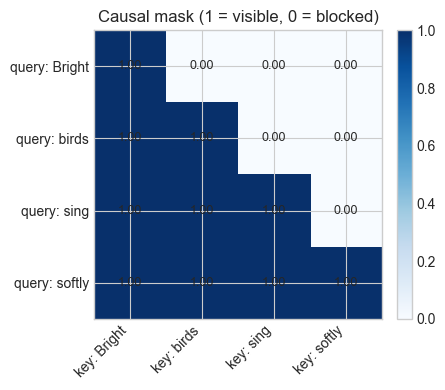

In [10]:
mask_tokens = ["Bright", "birds", "sing", "softly"]
causal_mask = torch.tril(torch.ones(len(mask_tokens), len(mask_tokens)))

print("Rows = the token we are currently updating.")
print("Columns = the tokens that are visible to it.")
print(rounded(causal_mask))
print()
for index, token in enumerate(mask_tokens):
    visible = mask_tokens[: index + 1]
    hidden = mask_tokens[index + 1 :]
    print(f"When updating {token!r}: visible -> {visible}, hidden -> {hidden}")

plot_matrix(
    causal_mask,
    [f"query: {token}" for token in mask_tokens],
    [f"key: {token}" for token in mask_tokens],
    "Causal mask (1 = visible, 0 = blocked)",
    cmap="Blues",
)


### What to notice

The mask is not mysterious once it is written as a visibility table. Each row is one token asking, "Which positions am I allowed to read from?"

### What this step contributes

The lower-triangular pattern turns an abstract language-model rule into something operational: every token may use its own position and anything to its left, but nothing to its right.

### Why it matters

This is what keeps next-token prediction honest. Without the mask, the model could quietly look at the answer token it is supposed to predict, and the whole training objective would collapse into leakage instead of learning.


### Worked Example: One Attention Row

To make $Q$, $K$, and $V$ feel less symbolic, we will now follow a single query position all the way through the head:

1. project its current state into query space
2. compare that query against every key
3. apply the causal mask
4. normalize the visible scores with softmax
5. use those weights to blend the value vectors into one context vector


Input states X:
tensor([[ 0.8260, -0.6030,  0.0140, -1.2440,  2.2650,  2.4080],
        [ 1.2650, -0.3020, -0.9480,  1.0600, -1.5950,  1.6650],
        [ 1.0430,  2.0970,  0.0600, -1.1560,  1.3430,  1.6230],
        [ 1.3520,  0.7910, -1.3740, -0.2560,  1.3160,  0.1310]])

Query vectors Q:
tensor([[ 0.6210,  0.9730, -0.7560],
        [ 1.8860, -0.9180,  0.7630],
        [ 0.8940,  1.8760,  0.2030],
        [ 1.5240,  0.6860, -1.5140]])

Key vectors K:
tensor([[ 1.3820, -0.0930,  1.8790],
        [ 0.1020,  0.1480, -0.3190],
        [ 1.5950,  0.5660,  1.3990],
        [ 1.7390, -0.7260, -0.1600]])

Value vectors V:
tensor([[ 0.1640,  1.5350,  1.6440],
        [-0.7630,  1.2200, -0.7460],
        [ 1.3540,  0.7120,  1.7780],
        [ 1.1400,  0.0100, -0.1270]])

Worked example for pos 2:
x_2 =
tensor([ 1.0430,  2.0970,  0.0600, -1.1560,  1.3430,  1.6230])

q_i = x_i @ W_Q =
tensor([0.8940, 1.8760, 0.2030])

Compare that query to every key:
pos 0 | raw=  1.442 | scaled=  0.832 | masked=

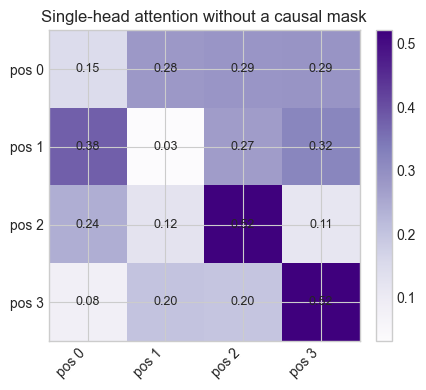

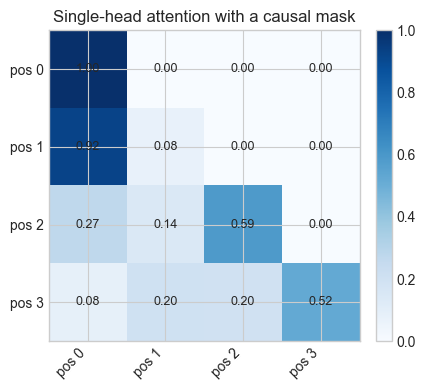

In [11]:
manual_states = combined_vectors.to(torch.float32)
labels = [f"pos {idx}" for idx in range(manual_states.shape[0])]

W_Q = torch.tensor([
    [0.7, 0.0, -0.2],
    [0.1, 0.5, 0.3],
    [-0.4, 0.2, 0.6],
    [0.3, -0.1, 0.2],
    [0.0, 0.4, -0.5],
    [0.2, 0.1, 0.4],
], dtype=torch.float32)
W_K = torch.tensor([
    [0.6, -0.2, 0.1],
    [0.2, 0.3, 0.0],
    [-0.1, 0.4, 0.5],
    [0.1, 0.2, -0.3],
    [0.5, -0.1, 0.2],
    [0.0, 0.3, 0.4],
], dtype=torch.float32)
W_V = torch.tensor([
    [0.2, 0.4, 0.1],
    [0.5, -0.2, 0.2],
    [0.0, 0.3, 0.6],
    [0.1, 0.1, -0.4],
    [0.4, 0.0, 0.2],
    [-0.2, 0.5, 0.3],
], dtype=torch.float32)

queries = manual_states @ W_Q
keys = manual_states @ W_K
values = manual_states @ W_V
raw_scores = queries @ keys.T
scaled_scores = raw_scores / math.sqrt(queries.shape[-1])
future_mask = torch.triu(torch.ones_like(scaled_scores), diagonal=1).bool()
masked_scores = scaled_scores.masked_fill(future_mask, float("-inf"))
unmasked_weights = F.softmax(scaled_scores, dim=-1)
masked_weights = F.softmax(masked_scores, dim=-1)
context_vectors = masked_weights @ values

focus_position = 2
focus_label = labels[focus_position]
focus_query = queries[focus_position]
focus_raw_scores = raw_scores[focus_position]
focus_scaled_scores = scaled_scores[focus_position]
focus_masked_scores = masked_scores[focus_position]
focus_weights = masked_weights[focus_position]
focus_contributions = focus_weights.unsqueeze(-1) * values
focus_context = context_vectors[focus_position]

print("Input states X:")
print(rounded(manual_states))
print("\nQuery vectors Q:")
print(rounded(queries))
print("\nKey vectors K:")
print(rounded(keys))
print("\nValue vectors V:")
print(rounded(values))

print(f"\nWorked example for {focus_label}:")
print(f"x_{focus_position} =")
print(rounded(manual_states[focus_position]))
print("\nq_i = x_i @ W_Q =")
print(rounded(focus_query))
print("\nCompare that query to every key:")
for label, raw_score, scaled_score, masked_score, weight in zip(
    labels,
    focus_raw_scores.tolist(),
    focus_scaled_scores.tolist(),
    focus_masked_scores.tolist(),
    focus_weights.tolist(),
):
    masked_text = "-inf" if math.isinf(masked_score) else f"{masked_score:.3f}"
    print(
        f"{label:>5} | raw={raw_score:>7.3f} | scaled={scaled_score:>7.3f} | "
        f"masked={masked_text:>7} | weight={weight:>6.3f}"
    )

print("\nWeighted value contributions for this row:")
for label, weight, value_vector, contribution_vector in zip(labels, focus_weights.tolist(), values, focus_contributions):
    print(f"{label:>5} | weight={weight:>6.3f} | value={rounded(value_vector)} | contribution={rounded(contribution_vector)}")

print("\nFinal context vector for this query:")
print(rounded(focus_context))
print("\nEach masked-attention row sums to:")
print(rounded(masked_weights.sum(dim=-1)))

plot_matrix(unmasked_weights, labels, labels, "Single-head attention without a causal mask", cmap="Purples")
plot_matrix(masked_weights, labels, labels, "Single-head attention with a causal mask", cmap="Blues")


### What to notice

The worked example follows one token all the way through attention: its query scores every key, the causal mask erases illegal future options, softmax turns the legal scores into weights, and those weights blend the value vectors into one context vector.

### What this step contributes

We are no longer staring at a compact formula and hoping it feels intuitive. We have unpacked the exact computation the head performs for one row of the attention matrix.

### Why it matters

Once this row-level calculation is clear, scaled dot-product attention stops feeling like magic. It becomes a sequence of ordinary tensor operations that just happen to be arranged in a very powerful way.


## From Explicit Math To Reusable PyTorch Modules

The by-hand calculations above gave us a close-up view of what attention is doing. The next step is to package those same mechanics into reusable PyTorch modules so we can train a real model without losing the conceptual thread.

The code below stays intentionally notebook-local, compact, and heavily documented. The aim is not to hide the transformer behind abstraction. The aim is to preserve the same step-by-step ideas while moving from one worked example to a full end-to-end language model.


In [12]:
def get_batch(token_ids, batch_size, block_size, device):
    """Sample random contiguous windows from a token stream for next-token training."""
    max_start = len(token_ids) - block_size - 1
    starts = torch.randint(0, max_start + 1, (batch_size,))

    # Each input window x is paired with the same window shifted by one token to form y.
    x = torch.stack([token_ids[start:start + block_size] for start in starts])
    y = torch.stack([token_ids[start + 1:start + block_size + 1] for start in starts])
    return x.to(device), y.to(device)


class CausalSelfAttention(nn.Module):
    """One attention head with a lower-triangular causal mask."""

    def __init__(self, d_model, head_size, block_size):
        super().__init__()
        self.query = nn.Linear(d_model, head_size, bias=False)
        self.key = nn.Linear(d_model, head_size, bias=False)
        self.value = nn.Linear(d_model, head_size, bias=False)
        self.register_buffer("mask", torch.tril(torch.ones(block_size, block_size)))

    def forward(self, x, return_attention=False):
        """Project x into q, k, v, apply the mask, and optionally return the attention map."""
        _, time_steps, _ = x.shape

        # Queries ask what this position is looking for.
        q = self.query(x)
        # Keys describe what information each earlier position contains.
        k = self.key(x)
        # Values are the vectors that will actually be mixed together.
        v = self.value(x)

        scores = (q @ k.transpose(-2, -1)) / math.sqrt(k.shape[-1])
        scores = scores.masked_fill(self.mask[:time_steps, :time_steps] == 0, float("-inf"))
        attention = F.softmax(scores, dim=-1)
        out = attention @ v
        if return_attention:
            return out, attention
        return out


class MultiHeadAttention(nn.Module):
    """Run several causal attention heads in parallel and mix their outputs back together."""

    def __init__(self, d_model, num_heads, block_size):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        head_size = d_model // num_heads
        self.heads = nn.ModuleList([
            CausalSelfAttention(d_model, head_size, block_size) for _ in range(num_heads)
        ])
        self.proj = nn.Linear(d_model, d_model)

    def forward(self, x, return_attention=False):
        """Concatenate per-head updates and project them back into the residual-stream width."""
        if return_attention:
            head_outputs = []
            head_weights = []
            for head in self.heads:
                out, weights = head(x, return_attention=True)
                head_outputs.append(out)
                head_weights.append(weights)
            combined = torch.cat(head_outputs, dim=-1)
            projected = self.proj(combined)
            attention_stack = torch.stack(head_weights, dim=1)
            return projected, attention_stack

        combined = torch.cat([head(x) for head in self.heads], dim=-1)
        return self.proj(combined)


class TransformerMLP(nn.Module):
    """The position-wise feed-forward sublayer inside a transformer block."""

    def __init__(self, d_model, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, hidden_dim),
            # We use GeLU because GPT-style transformers prefer a smooth activation over a hard threshold.
            nn.GELU(),
            nn.Linear(hidden_dim, d_model),
        )

    def forward(self, x):
        """Expand features, apply GeLU, and project back into the residual-stream width."""
        return self.net(x)


class TransformerBlock(nn.Module):
    """A pre-norm transformer block that reads from and writes back to the same residual stream."""

    def __init__(self, d_model, num_heads, block_size, mlp_hidden_dim):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = MultiHeadAttention(d_model, num_heads, block_size)
        self.ln2 = nn.LayerNorm(d_model)
        self.mlp = TransformerMLP(d_model, mlp_hidden_dim)

    def forward(self, x):
        """Apply attention and MLP updates, each time adding the update back to x."""
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x


class TinyTransformerLM(nn.Module):
    """A tiny decoder-only language model for educational experiments."""

    def __init__(self, vocab_size, d_model, num_heads, num_layers, block_size, mlp_hidden_dim):
        super().__init__()
        self.block_size = block_size
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.position_embedding = nn.Embedding(block_size, d_model)
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, num_heads, block_size, mlp_hidden_dim)
            for _ in range(num_layers)
        ])
        self.final_norm = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, idx, targets=None, return_first_attention=False):
        """Map token ids to logits, and optionally return the first block's attention map."""
        _, time_steps = idx.shape
        if time_steps > self.block_size:
            raise ValueError(f"Sequence length {time_steps} exceeds block size {self.block_size}.")

        positions = torch.arange(time_steps, device=idx.device)

        # Token embeddings answer "what token is this?"
        # Position embeddings answer "where is it in the sequence?"
        x = self.token_embedding(idx) + self.position_embedding(positions)[None, :, :]

        first_attention = None
        for block_index, block in enumerate(self.blocks):
            if return_first_attention and block_index == 0:
                # For visualization we optionally unpack the first block into explicit steps.
                attn_input = block.ln1(x)
                attn_out, first_attention = block.attn(attn_input, return_attention=True)
                x = x + attn_out
                x = x + block.mlp(block.ln2(x))
            else:
                x = block(x)

        x = self.final_norm(x)
        logits = self.lm_head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))

        if return_first_attention:
            return logits, loss, first_attention
        return logits, loss


@torch.no_grad()
def sample_from_model(model, prompt, encode, decode, max_new_tokens=60, temperature=0.8, top_k=8):
    """Autoregressively sample from the model one token at a time."""
    model.eval()
    idx = torch.tensor([encode(prompt)], dtype=torch.long, device=device)
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -model.block_size:]
        logits, _ = model(idx_cond)
        next_token_logits = logits[:, -1, :]
        if temperature <= 0:
            next_idx = next_token_logits.argmax(dim=-1, keepdim=True)
            idx = torch.cat([idx, next_idx], dim=1)
            continue

        next_token_logits = next_token_logits / temperature
        if top_k is not None:
            values, _ = torch.topk(next_token_logits, min(top_k, next_token_logits.shape[-1]))
            cutoff = values[:, [-1]]
            next_token_logits = torch.where(
                next_token_logits < cutoff,
                torch.full_like(next_token_logits, float("-inf")),
                next_token_logits,
            )
        probs = F.softmax(next_token_logits, dim=-1)
        next_idx = torch.multinomial(probs, num_samples=1)
        idx = torch.cat([idx, next_idx], dim=1)
    return decode(idx[0].tolist())


@torch.no_grad()
def trace_generation(model, prompt, encode, decode, max_new_tokens=10):
    """Return a step-by-step record of greedy generation for inspection."""
    model.eval()
    idx = torch.tensor([encode(prompt)], dtype=torch.long, device=device)
    trace = []
    for step in range(max_new_tokens):
        idx_cond = idx[:, -model.block_size:]
        logits, _ = model(idx_cond)
        probs = F.softmax(logits[:, -1, :], dim=-1)
        top_probs, top_ids = torch.topk(probs, k=min(5, probs.shape[-1]))
        chosen = probs.argmax(dim=-1, keepdim=True)
        trace.append(
            {
                "step": step + 1,
                "context": decode(idx[0].tolist()),
                "chosen_token": decode([int(chosen.item())]),
                "top_choices": [
                    (decode([int(token_id)]), float(prob))
                    for token_id, prob in zip(top_ids[0], top_probs[0])
                ],
            }
        )
        idx = torch.cat([idx, chosen], dim=1)
    return trace, decode(idx[0].tolist())


@torch.no_grad()
def estimate_loss(model, token_ids, batch_size, block_size, eval_steps):
    """Average the loss over a few random batches so we can monitor progress."""
    model.eval()
    losses = []
    for _ in range(eval_steps):
        xb, yb = get_batch(token_ids, batch_size, block_size, device)
        _, loss = model(xb, yb)
        losses.append(loss.item())
    model.train()
    return sum(losses) / len(losses)


def train_language_model(
    model,
    train_ids,
    val_ids,
    *,
    steps,
    batch_size,
    block_size,
    learning_rate,
    eval_interval,
    eval_steps,
    label,
):
    """Train a tiny language model while periodically measuring train/validation loss."""
    # We use AdamW because it is the standard optimizer family for modern transformer training.
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
    history = {"steps": [], "train": [], "val": []}

    initial_train = estimate_loss(model, train_ids, batch_size, block_size, eval_steps)
    initial_val = estimate_loss(model, val_ids, batch_size, block_size, eval_steps)
    history["steps"].append(0)
    history["train"].append(initial_train)
    history["val"].append(initial_val)
    print(f"{label} | step   0 | train {initial_train:.3f} | val {initial_val:.3f}")

    model.train()
    for step in range(1, steps + 1):
        xb, yb = get_batch(train_ids, batch_size, block_size, device)
        _, loss = model(xb, yb)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        if step % eval_interval == 0 or step == steps:
            train_loss = estimate_loss(model, train_ids, batch_size, block_size, eval_steps)
            val_loss = estimate_loss(model, val_ids, batch_size, block_size, eval_steps)
            history["steps"].append(step)
            history["train"].append(train_loss)
            history["val"].append(val_loss)
            print(f"{label} | step {step:>3} | train {train_loss:.3f} | val {val_loss:.3f}")

    return history


print("Model, generation, and training helpers are ready.")


Model, generation, and training helpers are ready.


## Phase 5. Multi-Head Attention

A single attention head can only express one pattern of relevance at a time. Multi-head attention lets the model ask several relational questions in parallel and then combine the answers back into one shared representation.

Conceptually:

$$
\text{MultiHead}(X) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h)W_O
$$

Why is that useful? Because language rarely demands only one kind of connection at once. Different heads can focus on different structure, for example:

- one head can stay local and track nearby syntax
- another can carry subject or object information across a clause
- another can keep track of repeated entities, lists, or quoted text
- another can move a factual cue from earlier in the context to the current prediction point

The important idea is not that every head becomes perfectly interpretable, but that the model is no longer forced to compress all relational structure into one attention map.


Input shape: (1, 4, 6)
Attention map stack shape: (1, 2, 4, 4)
Combined output shape: (1, 4, 6)
Combined output vectors:
tensor([[-1.4130,  0.9090, -0.6460, -0.4470,  0.5970, -0.2700],
        [-0.9600,  0.3920, -0.4040, -0.1920,  0.5700,  0.0640],
        [-1.1190,  0.1790, -0.2290, -0.3180,  0.6300,  0.2670],
        [-1.1020,  0.1860, -0.2630, -0.2800,  0.6370,  0.2660]])

Head 1 focus for pos 3:
  attends to pos 1 with weight 0.586
  attends to pos 0 with weight 0.162
  attends to pos 3 with weight 0.148
  attends to pos 2 with weight 0.104
  head-specific context vector:
tensor([-0.4110,  0.0360,  0.0030])

Head 2 focus for pos 3:
  attends to pos 0 with weight 0.370
  attends to pos 1 with weight 0.274
  attends to pos 2 with weight 0.193
  attends to pos 3 with weight 0.164
  head-specific context vector:
tensor([ 0.6850, -0.7300, -0.9010])


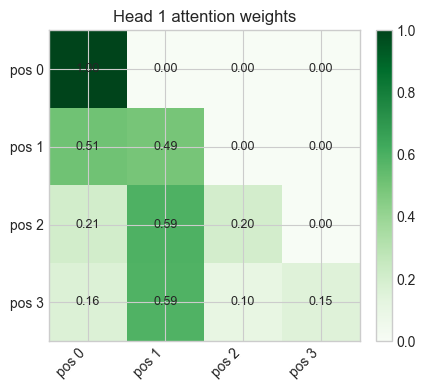

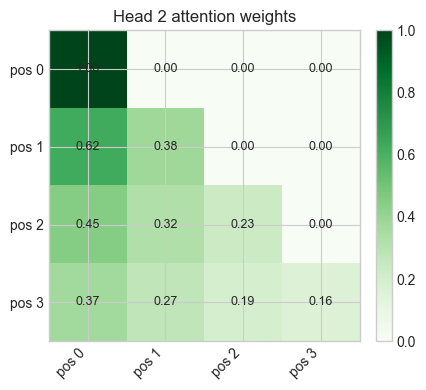

In [13]:
attention_demo = combined_vectors.unsqueeze(0)
multi_head = MultiHeadAttention(d_model=embedding_dim, num_heads=2, block_size=4)
multi_head_out, head_maps = multi_head(attention_demo, return_attention=True)

focus_token_index = 3

print("Input shape:", tuple(attention_demo.shape))
print("Attention map stack shape:", tuple(head_maps.shape))
print("Combined output shape:", tuple(multi_head_out.shape))
print("Combined output vectors:")
print(rounded(multi_head_out[0]))

for head_index, head in enumerate(multi_head.heads, start=1):
    head_out, head_weights = head(attention_demo, return_attention=True)
    row_weights = head_weights[0, focus_token_index]

    print(f"\nHead {head_index} focus for {labels[focus_token_index]}:")
    for token_index in torch.argsort(row_weights, descending=True).tolist():
        print(f"  attends to {labels[token_index]} with weight {row_weights[token_index].item():.3f}")
    print("  head-specific context vector:")
    print(rounded(head_out[0, focus_token_index]))

for head_index in range(head_maps.shape[1]):
    plot_matrix(
        head_maps[0, head_index],
        labels,
        labels,
        f"Head {head_index + 1} attention weights",
        cmap="Greens",
    )


### What to notice

The same token now receives several different updates in parallel. Each head builds its own attention map and its own context vector before the model mixes those views back together.

### What this step contributes

We have expanded the model's expressive range. Instead of asking one question about the sequence, the block can ask several narrower questions at the same time and combine the resulting evidence.

### Why it matters

Multi-head attention is useful because language carries many overlapping structures at once: word order, syntax, entity identity, factual patterns, and longer-range discourse cues. A single head is often too narrow to juggle all of that gracefully.


## Phase 6. MLP, Residual Connections, And The Residual Stream

Attention tells a position **where to look**. The MLP tells that position **how to rewrite what it now knows**.

The representation that flows from the embeddings, through every block, all the way to the logits is called the **residual stream**. It is the model's running internal state.

Each sublayer does not replace that state. Instead, it proposes an update and adds the update back in through a **residual connection**:

$$
x^{\ell + 1/2} = x^\ell + \mathrm{Attn}(\mathrm{LN}(x^\ell))
$$

$$
x^{\ell + 1} = x^{\ell + 1/2} + \mathrm{MLP}(\mathrm{LN}(x^{\ell + 1/2}))
$$

This gives us a useful mental model:

- the residual stream is the running draft of the representation
- attention writes cross-token edits into that draft
- the MLP writes within-token feature edits into that draft

Activation functions matter here too. Without a nonlinearity, the MLP would collapse into one more linear map. We use **GeLU** because it is smooth, keeps small activations partially alive instead of hard-thresholding them, and has become the standard activation in GPT-style decoder blocks.


In [14]:
residual_input = attention_demo.clone()
ln1 = nn.LayerNorm(embedding_dim)
ln2 = nn.LayerNorm(embedding_dim)
residual_attention = MultiHeadAttention(d_model=embedding_dim, num_heads=2, block_size=4)
residual_mlp = TransformerMLP(d_model=embedding_dim, hidden_dim=18)

# The residual stream is the running state that flows through the whole block.
attention_update = residual_attention(ln1(residual_input))
after_attention = residual_input + attention_update

# The MLP reads the updated residual stream and writes another additive update back into it.
mlp_update = residual_mlp(ln2(after_attention))
after_mlp = after_attention + mlp_update

token_before = residual_input[0, 0]
token_attention_update = attention_update[0, 0]
token_after_attention = after_attention[0, 0]
token_mlp_update = mlp_update[0, 0]
token_after_block = after_mlp[0, 0]

print("First token before the block:")
print(rounded(token_before))
print("\nAttention update written into the residual stream:")
print(rounded(token_attention_update))
print("\nFirst token after attention + residual:")
print(rounded(token_after_attention))
print("\nMLP update written into the residual stream:")
print(rounded(token_mlp_update))
print("\nFirst token after the full block:")
print(rounded(token_after_block))
print("\nUpdate norms:")
print(f"attention update norm = {token_attention_update.norm().item():.3f}")
print(f"MLP update norm       = {token_mlp_update.norm().item():.3f}")
print("\nResidual-stream identity checks:")
print("after attention == before + attention update:", torch.allclose(token_after_attention, token_before + token_attention_update))
print("after block == after attention + mlp update:", torch.allclose(token_after_block, token_after_attention + token_mlp_update))


First token before the block:
tensor([ 0.8260, -0.6030,  0.0140, -1.2440,  2.2650,  2.4080])

Attention update written into the residual stream:
tensor([-0.1480,  0.1750,  0.5730,  0.0860,  0.5050,  0.3720])

First token after attention + residual:
tensor([ 0.6790, -0.4280,  0.5870, -1.1580,  2.7700,  2.7810])

MLP update written into the residual stream:
tensor([-0.2200,  0.0920,  0.0970, -0.2960, -0.1100,  0.4220])

First token after the full block:
tensor([ 0.4590, -0.3360,  0.6840, -1.4540,  2.6600,  3.2030])

Update norms:
attention update norm = 0.884
MLP update norm       = 0.586

Residual-stream identity checks:
after attention == before + attention update: True
after block == after attention + mlp update: True


### What to notice

The incoming token state survives the whole block. Attention writes one update into it, the MLP writes another, and the stream keeps moving forward.

### What this step contributes

We can now name the two ideas that often get blurred together. The **residual stream** is the running hidden state itself. The **residual connections** are the add-back operations that let each sublayer modify that state without discarding it.

### Why it matters

Deep transformers work because information is preserved while new edits accumulate. Earlier evidence is not erased every time a new sublayer runs; it stays available inside the stream, which is one reason these models are both trainable and interpretable.


## Phase 7. Transformer Block Composition

By this point we have every ingredient of a decoder-only transformer. The remaining step is composition: keep one shared residual stream, apply several transformer blocks in sequence, normalize the final states, and project those states into vocabulary space.

The visual below shows that composition before we instantiate a small PyTorch model and verify the tensor shapes numerically.


In [15]:
from IPython.display import SVG, display

composition_svg = f"""
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 1240 420" width="1240" height="420" role="img" aria-label="A transformer block composition diagram from token ids to logits.">
  <rect x="0" y="0" width="1240" height="420" rx="28" fill="#f8fafc"/>
  <g filter="url(#softShadow)">
    <rect x="28" y="24" width="1184" height="372" rx="30" fill="url(#panelBg)" stroke="#d9e2ef" stroke-width="1.5"/>
  </g>
  <rect x="28" y="24" width="1184" height="372" rx="30" fill="url(#dotGrid)" opacity="0.22"/>

  {svg_pill(60, 48, 152, 28, 'COMPOSITION VIEW', fill='#e8f0ff', stroke='#c7dafd', text_fill='#1d4ed8', font_size=11)}
  {svg_multiline(60, 95, ['From token ids to logits'], font_size=28, fill='#0f172a', weight=800, anchor='start')}
  {svg_multiline(60, 124, ['A decoder-only language model keeps one residual stream alive while repeated blocks refine it step by step.'], font_size=15, line_height=20, fill='#475569', anchor='start')}

  <line x1="84" y1="242" x2="1156" y2="242" stroke="#cbd5e1" stroke-width="4" stroke-linecap="round" opacity="0.6"/>

  {svg_box(74, 190, 138, 94, 'Token ids', ['discrete indices from', 'the tokenizer'], fill='#e6edf8', stroke='#c4d3e8', accent='#94a3b8')}
  {svg_box(244, 190, 156, 94, 'Token embeddings', ['learned vectors for', 'token identity'], fill='#e9f6ea', stroke='#c6e4cb', accent='#66bb84')}
  {svg_box(432, 190, 170, 94, 'Add positions', ['inject order into', 'the same stream'], fill='#eef6ff', stroke='#c9dcff', accent='#60a5fa')}

  <g filter="url(#softShadow)">
    <rect x="666" y="182" width="184" height="108" rx="24" fill="#fff6dd" stroke="#f3d285" stroke-width="2"/>
    <rect x="652" y="196" width="184" height="108" rx="24" fill="#fff1cf" stroke="#f3d285" stroke-width="2" opacity="0.95"/>
    <rect x="638" y="210" width="184" height="108" rx="24" fill="#ffe9b8" stroke="#f3d285" stroke-width="2"/>
  </g>
  {svg_pill(708, 158, 94, 24, 'repeat x N', fill='#fff7df', stroke='#f1cd79', text_fill='#8a5b00', font_size=11)}
  {svg_multiline(730, 248, ['Transformer', 'blocks'], font_size=20, line_height=20, fill='#0f172a', weight=800)}
  {svg_multiline(730, 278, ['LayerNorm -> Masked MHA -> Add', 'LayerNorm -> GeLU MLP -> Add'], font_size=13, line_height=18, fill='#475569')}

  {svg_box(874, 190, 140, 94, 'Final norm', ['stabilize the final', 'hidden states'], fill='#f8fafc', stroke='#d4dce8', accent='#94a3b8')}
  {svg_box(1044, 190, 128, 94, 'LM head', ['linear map into', 'vocabulary space'], fill='#fde8ea', stroke='#f0c4c8', accent='#e88d93')}

  {svg_arrow(212, 242, 244, 242)}
  {svg_arrow(400, 242, 432, 242)}
  {svg_arrow(602, 242, 638, 242)}
  {svg_arrow(822, 242, 874, 242)}
  {svg_arrow(1014, 242, 1044, 242)}
  {svg_arrow(1172, 242, 1200, 242)}

  {svg_multiline(1120, 170, ['logits: one score', 'per vocabulary item'], font_size=13, line_height=18, fill='#475569', anchor='middle')}
  {svg_multiline(620, 350, ['Repeated blocks do the real representational work. Everything before them prepares the stream; everything after them reads it out.'], font_size=15, fill='#64748b', anchor='middle')}
</svg>
"""

display(SVG(composition_svg))

demo_model = TinyTransformerLM(
    vocab_size=len(preview_chars),
    d_model=48,
    num_heads=4,
    num_layers=2,
    block_size=32,
    mlp_hidden_dim=96,
).to(device)

demo_text = toy_preview_text[:33]
demo_ids = torch.tensor(preview_encode(demo_text), dtype=torch.long)
xb = demo_ids[:-1].unsqueeze(0).to(device)
yb = demo_ids[1:].unsqueeze(0).to(device)
logits, loss = demo_model(xb, yb)

print("Demo text:", repr(demo_text))
print("Input batch shape:", tuple(xb.shape))
print("Logits shape:", tuple(logits.shape))
print("One-step cross-entropy loss:", round(loss.item(), 3))
print("Parameter count:", f"{count_parameters(demo_model):,}")


Demo text: 'The capital of Kenya is Nairobi.\n'
Input batch shape: (1, 32)
Logits shape: (1, 32, 43)
One-step cross-entropy loss: 3.96
Parameter count: 43,435


### What to notice

The composition diagram and the printed tensor shapes are telling the same story from two angles: visually, we can see how the blocks fit together; numerically, we can confirm that the assembled model produces one logit vector per time step and vocabulary item.

### What this step contributes

The notebook has crossed an important threshold. We are no longer studying isolated parts of a transformer; we are watching those parts act as one end-to-end computation.

### Why it matters

This is the bridge from architectural understanding to trainable code. Once the model can map context tokens to logits and loss, every later section on prediction, generation, and training becomes a direct consequence of the same forward pass.


## Phase 8. Logits And Next-Token Prediction

The language model does not output a token directly. It outputs **logits**: one unnormalized score for every vocabulary item at every position.

Those scores become probabilities only after a softmax:

$$
P(\text{next token} \mid \text{context}) = \text{softmax}(\text{logits})
$$

A useful intuition is this:

- the hidden state says what the model currently knows
- the LM head turns that state into a score for each token in the vocabulary
- softmax converts relative score differences into a probability distribution

The ranking already lives in the logits; softmax just turns that ranking into something we can interpret and sample from.


In [16]:
last_position_logits = logits[0, -1].detach().cpu()
last_position_probs = F.softmax(last_position_logits, dim=-1)
top_logits, top_ids = torch.topk(last_position_logits, k=5)
top_probs = last_position_probs[top_ids]
context_text = preview_decode(xb[0].detach().cpu().tolist())
target_token = preview_itos[int(yb[0, -1].detach().cpu().item())]
target_probability = last_position_probs[int(yb[0, -1].detach().cpu().item())].item()

print("Context seen by the model:")
print(repr(context_text))
print("\nTrue next token:", repr(target_token))
print("\nTop 5 next-token logits and probabilities:")
for rank, (token_id, logit_value, probability) in enumerate(zip(top_ids.tolist(), top_logits.tolist(), top_probs.tolist()), start=1):
    print(
        f"{rank}. token={repr(preview_itos[token_id])} "
        f"logit={logit_value:.3f} probability={probability:.3f}"
    )

print(f"\nProbability assigned to the true next token {repr(target_token)}: {target_probability:.3f}")
print(f"Logit gap between rank 1 and rank 2: {(top_logits[0] - top_logits[1]).item():.3f}")


Context seen by the model:
'The capital of Kenya is Nairobi.'

True next token: '\n'

Top 5 next-token logits and probabilities:
1. token='E' logit=0.752 probability=0.046
2. token='m' logit=0.733 probability=0.045
3. token='8' logit=0.676 probability=0.042
4. token=' ' logit=0.619 probability=0.040
5. token='b' logit=0.606 probability=0.040

Probability assigned to the true next token '\n': 0.013
Logit gap between rank 1 and rank 2: 0.019


### What to notice

The final hidden state has been turned into a ranked competition among vocabulary items. The logits show raw preference strength; the probabilities show that same preference after normalization.

### What this step contributes

We have arrived at the exact interface between internal representation and observable behavior. Everything the model has inferred from the context is now compressed into one distribution over possible next tokens.

### Why it matters

Next-token prediction is the whole game. Training changes the logits so the correct continuation becomes more likely, and generation simply reuses that same distribution one step at a time.


## Phase 9. Tiny Autoregressive Generation Demo

Generation is just repeated next-token prediction. We feed in the current context, read the final-position distribution, choose a token, append it to the context, and run the model again.

That feedback loop is what makes autoregressive models feel sequential: every new token becomes part of the evidence for the next decision.

Before training, the model has no real language knowledge, so the output is mostly noise. That is useful to see because it gives us a baseline. Later, when training improves the distribution, we will know exactly what changed.


In [17]:
generation_trace, untrained_sample = trace_generation(
    demo_model,
    prompt="The capital of ",
    encode=preview_encode,
    decode=preview_decode,
    max_new_tokens=10,
)

print("Untrained generation trace:")
for item in generation_trace:
    print(f"\nStep {item['step']:>2}")
    print(f"  context: {repr(item['context'])}")
    print(f"  chosen next token: {repr(item['chosen_token'])}")
    print("  top choices:")
    for token, prob in item["top_choices"]:
        print(f"    {repr(token):>6} -> {prob:.3f}")

print("\nFinal generated text:")
print(untrained_sample)


Untrained generation trace:

Step  1
  context: 'The capital of '
  chosen next token: 'R'
  top choices:
       'R' -> 0.074
       'y' -> 0.062
       '6' -> 0.052
       't' -> 0.039
       'C' -> 0.035

Step  2
  context: 'The capital of R'
  chosen next token: 'T'
  top choices:
       'T' -> 0.090
       'z' -> 0.063
       'E' -> 0.063
       '.' -> 0.052
       'd' -> 0.051

Step  3
  context: 'The capital of RT'
  chosen next token: 't'
  top choices:
       't' -> 0.065
       'p' -> 0.064
       '4' -> 0.057
       'w' -> 0.047
       'f' -> 0.043

Step  4
  context: 'The capital of RTt'
  chosen next token: 'u'
  top choices:
       'u' -> 0.112
       'z' -> 0.046
       'E' -> 0.045
       'a' -> 0.042
       ' ' -> 0.042

Step  5
  context: 'The capital of RTtu'
  chosen next token: 'E'
  top choices:
       'E' -> 0.065
       'h' -> 0.060
       '.' -> 0.055
       'f' -> 0.055
       'm' -> 0.053

Step  6
  context: 'The capital of RTtuE'
  chosen next token: 'x'
  to

### What to notice

The trace makes generation feel mechanical in the best possible way. At each step the model sees a context, forms a distribution, chooses one token, and then has to live with that choice on the next step.

### What this step contributes

We have moved from static prediction to a running loop. The context keeps growing, and every new token changes the evidence available for the next decision.

### Why it matters

This is exactly how larger language models generate text too. Training does not change the loop itself; it changes the quality of the probability distribution being reused inside that loop.


## Phase 10. Stage A Training On Tiny Synthetic Text

Now we train on a tiny corpus we can understand almost line by line.

This stage is intentionally repetitive and structured. That is a feature, not a limitation. When the data contains simple factual and grammar-like patterns, we can usually tell what the model has learned by looking at the generations and the loss curve.

Stage A is where the notebook turns from a guided tour of transformer mechanics into a controlled learning experiment:

- we know what patterns exist in the corpus
- we can inspect how sequences and shifted targets are formed
- we can watch loss fall on a task that is small enough to reason about directly

For optimization we use **AdamW**, the optimizer family most commonly used in transformer training. It combines adaptive gradient updates with decoupled weight decay, which makes it a strong default for GPT-style models.


In [18]:
stage_a_corpus = "\n".join(toy_sentences * 24)
stage_a_chars, stage_a_stoi, stage_a_itos, stage_a_encode, stage_a_decode = build_char_tokenizer(stage_a_corpus)
stage_a_ids = torch.tensor(stage_a_encode(stage_a_corpus), dtype=torch.long)
stage_a_split = int(0.9 * len(stage_a_ids))
stage_a_train_ids = stage_a_ids[:stage_a_split]
stage_a_val_ids = stage_a_ids[stage_a_split:]

sample_window = stage_a_train_ids[:48]
sample_targets = stage_a_train_ids[1:49]

print("Stage A corpus characters:", len(stage_a_ids))
print("Stage A vocabulary size:", len(stage_a_chars))
print("Training characters:", len(stage_a_train_ids))
print("Validation characters:", len(stage_a_val_ids))
print("\nCorpus preview:")
print(stage_a_corpus[:350])

print("\nExample training window x:")
print(repr(stage_a_decode(sample_window.tolist())))
print("\nShifted targets y:")
print(repr(stage_a_decode(sample_targets.tolist())))

print("\nFirst 12 x -> y training pairs:")
for x_id, y_id in zip(sample_window[:12], sample_targets[:12]):
    print(f"{repr(stage_a_itos[int(x_id)])} -> {repr(stage_a_itos[int(y_id)])}")


Stage A corpus characters: 8687
Stage A vocabulary size: 43
Training characters: 7818
Validation characters: 869

Corpus preview:
The capital of Kenya is Nairobi.
The capital of Italy is Rome.
The capital of Japan is Tokyo.
The capital of Brazil is Brasilia.
The capital of Egypt is Cairo.
The capital of India is New Delhi.
2 plus 2 equals 4.
3 plus 3 equals 6.
4 plus 4 equals 8.
The red bird sings at dawn.
The blue bird sings at dusk.
A small fox sees the moon.
A small fox se

Example training window x:
'The capital of Kenya is Nairobi.\nThe capital of '

Shifted targets y:
'he capital of Kenya is Nairobi.\nThe capital of I'

First 12 x -> y training pairs:
'T' -> 'h'
'h' -> 'e'
'e' -> ' '
' ' -> 'c'
'c' -> 'a'
'a' -> 'p'
'p' -> 'i'
'i' -> 't'
't' -> 'a'
'a' -> 'l'
'l' -> ' '
' ' -> 'o'


### What to notice

The corpus is small enough to read, but it has already been converted into the exact form a language model expects: one long token stream plus shifted targets for next-token prediction.

### What this step contributes

This is the moment where the training objective becomes concrete. The model is not memorizing isolated labels; it is repeatedly learning from overlapping windows cut out of a continuous sequence.

### Why it matters

Tiny synthetic data is valuable because it keeps the supervision signal legible. When the model improves here, we can usually point to the pattern it learned rather than just observing a mysterious loss decrease.


Samples before training:

Prompt: 'The capital of Kenya is '


The capital of Kenya is 48Erq8DcEIgEfyz8Dfyh4rBRgnxzllsIrIEnEsDl

Prompt: '2 plus 2 equals '


2 plus 2 equals gc
zdpIi4cErhfCzahsDx.k6sc4l83CkqmIqkt2D

Prompt: 'A small fox '


A small fox gDopqNanmEfolCzls2gq
tDBrBt8en4t48EkfoB8



Stage A | step   0 | train 3.946 | val 3.936


Stage A | step  20 | train 2.059 | val 2.064


Stage A | step  40 | train 1.573 | val 1.527


Stage A | step  60 | train 1.223 | val 1.212


Stage A | step  80 | train 0.900 | val 0.904


Stage A | step 100 | train 0.629 | val 0.624


Stage A | step 120 | train 0.400 | val 0.397


Stage A | step 140 | train 0.276 | val 0.271


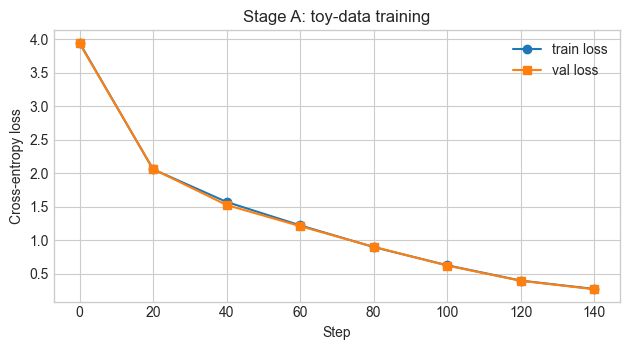

Samples after training:

Prompt: 'The capital of Kenya is '
The capital of Kenya is Nairobi.
The capital of Ital

Prompt: '2 plus 2 equals '


2 plus 2 equals 4.
3 plus equals 8.
The capi

Prompt: 'A small fox '
A small fox sees the moon.
A small fofox



In [19]:
stage_a_model = TinyTransformerLM(
    vocab_size=len(stage_a_chars),
    d_model=64,
    num_heads=4,
    num_layers=2,
    block_size=64,
    mlp_hidden_dim=128,
).to(device)

stage_a_prompts = [
    "The capital of Kenya is ",
    "2 plus 2 equals ",
    "A small fox ",
]

print("Samples before training:\n")
for prompt in stage_a_prompts:
    print(f"Prompt: {repr(prompt)}")
    print(sample_from_model(stage_a_model, prompt, stage_a_encode, stage_a_decode, max_new_tokens=40))
    print()

stage_a_history = train_language_model(
    stage_a_model,
    stage_a_train_ids,
    stage_a_val_ids,
    steps=140,
    batch_size=24,
    block_size=64,
    learning_rate=3e-3,
    eval_interval=20,
    eval_steps=6,
    label="Stage A",
)
plot_loss_curves(stage_a_history, "Stage A: toy-data training")

print("Samples after training:\n")
for prompt in stage_a_prompts:
    print(f"Prompt: {repr(prompt)}")
    print(sample_from_model(stage_a_model, prompt, stage_a_encode, stage_a_decode, max_new_tokens=28, temperature=0.4, top_k=4))
    print()


### What to notice

We can now compare three moments of the same model: before it has learned anything useful, while optimization is reducing loss, and after the parameters have adjusted to the toy corpus.

### What this step contributes

This is the first time the notebook stops being only an explanation and becomes an experiment. The embeddings, attention weights, MLP weights, and output projection are all being pushed toward better next-token predictions on data whose structure we actually understand.

### Why it matters

Stage A is the clearest proof that the scratch-built transformer is not just architecturally correct on paper. It is capable of learning a real distribution, and because the corpus is so interpretable, we can see what that learning looks like.


## Phase 11. Stage B Training On A Small Project Gutenberg Subset

Stage A was deliberately controlled: tiny repeated patterns, clean targets, and short-range structure we could inspect almost line by line.

Stage B asks a more realistic question: can the same decoder-only transformer recipe still improve when the text becomes messy, literary, and less repetitive?

We will use a small cleaned subset of *Alice's Adventures in Wonderland* from Project Gutenberg. The goal is still next-token prediction, but the learning problem is now richer:

- punctuation and formatting matter
- character transitions are less repetitive
- useful context can span farther than a single template sentence

This is the bridge from a didactic toy world to real narrative text while staying light enough for Colab.


In [20]:
gutenberg_url = "https://www.gutenberg.org/cache/epub/11/pg11.txt"
raw_gutenberg = requests.get(gutenberg_url, timeout=30).text


def strip_gutenberg_boilerplate(text):
    """Remove Project Gutenberg header/footer markers so the model sees only book content."""
    start_match = re.search(r"\*\*\* START OF THE PROJECT GUTENBERG EBOOK.*?\*\*\*", text)
    end_match = re.search(r"\*\*\* END OF THE PROJECT GUTENBERG EBOOK.*?\*\*\*", text)
    start = start_match.end() if start_match else 0
    end = end_match.start() if end_match else len(text)
    return text[start:end].strip()


# Keep the preprocessing readable: normalize punctuation, keep ASCII text, and limit the subset size.
alice_text = strip_gutenberg_boilerplate(raw_gutenberg)
alice_text = alice_text.replace("\r", "")
alice_text = alice_text.translate(
    str.maketrans(
        {
            "“": '"',
            "”": '"',
            "‘": "'",
            "’": "'",
            "—": "-",
            "–": "-",
            "…": "...",
        }
    )
)
alice_text = "".join(ch for ch in alice_text if ch == "\n" or 32 <= ord(ch) < 127)
alice_text = re.sub(r"\n{3,}", "\n\n", alice_text)

# We keep only a compact slice so the notebook stays practical on CPU and Colab.
stage_b_corpus = alice_text[:50000]
stage_b_chars, stage_b_stoi, stage_b_itos, stage_b_encode, stage_b_decode = build_char_tokenizer(stage_b_corpus)
stage_b_ids = torch.tensor(stage_b_encode(stage_b_corpus), dtype=torch.long)
stage_b_split = int(0.9 * len(stage_b_ids))
stage_b_train_ids = stage_b_ids[:stage_b_split]
stage_b_val_ids = stage_b_ids[stage_b_split:]

print("Downloaded characters:", len(raw_gutenberg))
print("Stage B subset characters:", len(stage_b_corpus))
print("Stage B vocabulary size:", len(stage_b_chars))
print("Training characters:", len(stage_b_train_ids))
print("Validation characters:", len(stage_b_val_ids))
print("\nSubset preview:\n")
print(stage_b_corpus[:700])


Downloaded characters: 167713
Stage B subset characters: 50000
Stage B vocabulary size: 71
Training characters: 45000
Validation characters: 5000

Subset preview:

[Illustration]

Alice's Adventures in Wonderland

by Lewis Carroll

THE MILLENNIUM FULCRUM EDITION 3.0

Contents

 CHAPTER I.     Down the Rabbit-Hole
 CHAPTER II.    The Pool of Tears
 CHAPTER III.   A Caucus-Race and a Long Tale
 CHAPTER IV.    The Rabbit Sends in a Little Bill
 CHAPTER V.     Advice from a Caterpillar
 CHAPTER VI.    Pig and Pepper
 CHAPTER VII.   A Mad Tea-Party
 CHAPTER VIII.  The Queen's Croquet-Ground
 CHAPTER IX.    The Mock Turtle's Story
 CHAPTER X.     The Lobster Quadrille
 CHAPTER XI.    Who Stole the Tarts?
 CHAPTER XII.   Alice's Evidence

CHAPTER I.
Down the Rabbit-Hole

Alice was beginning to get very tired of sitting by her sister on the
bank, and of having


### What to notice

The input text is no longer a hand-built toy corpus. It now contains paragraph breaks, dialogue, punctuation, and the uneven rhythm of real prose.

### What this step contributes

We have crossed the key bridge of the lab: the exact same next-token machinery is now being asked to model a real narrative distribution rather than a synthetic teaching pattern.

### Why it matters

This is where the reader can see that transformers are not special-purpose pattern matchers. The same architecture that learned tiny templates can also begin to absorb literary text, provided we keep expectations and scale realistic.


Samples before training:

Prompt: 'Alice was '


Alice was kG?NJUcGnU(VYsibKU.Ra[ LXLMQcjpT0ug!x
SOd
ph:o M
'ViEAlMKRFYgl'ofSO 
ZOJZ-dU(tX*

Prompt: 'The Rabbit '


The Rabbit FlzAu!].N avA[ND(xFlCq[bbZa
Nh
g efeNrG xFgF"FQr*Dpru*wYrCI].)U"v"CE.(Y M?3Vi WF

Stage B | step   0 | train 4.402 | val 4.382


Stage B | step  20 | train 2.998 | val 3.105


Stage B | step  40 | train 2.772 | val 2.846


Stage B | step  60 | train 2.676 | val 2.724


Stage B | step  80 | train 2.609 | val 2.634


Stage B | step 100 | train 2.510 | val 2.618


Stage B | step 120 | train 2.526 | val 2.575


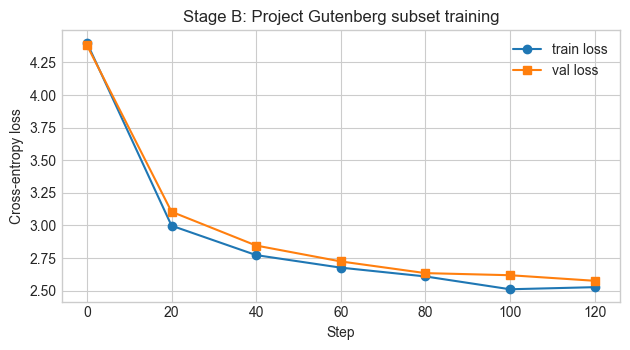

Samples after training:

Prompt: 'Alice was '


Alice was s to s he se o the towan wan the anthe sthe tithedad watoris

Prompt: 'The Rabbit '


The Rabbit it intheshe o the the s or the ser she
al an ane t an the s 



In [21]:
# We keep the model family the same as Stage A, but use a slightly larger context window for real text.
stage_b_model = TinyTransformerLM(
    vocab_size=len(stage_b_chars),
    d_model=64,
    num_heads=4,
    num_layers=2,
    block_size=96,
    mlp_hidden_dim=128,
).to(device)

stage_b_prompts = [
    "Alice was ",
    "The Rabbit ",
]

print("Samples before training:\n")
for prompt in stage_b_prompts:
    print(f"Prompt: {repr(prompt)}")
    print(sample_from_model(stage_b_model, prompt, stage_b_encode, stage_b_decode, max_new_tokens=80, temperature=0.9, top_k=10))
    print()

# The run is intentionally short: long enough to see learning, short enough to stay notebook-friendly.
stage_b_history = train_language_model(
    stage_b_model,
    stage_b_train_ids,
    stage_b_val_ids,
    steps=120,
    batch_size=16,
    block_size=96,
    learning_rate=2e-3,
    eval_interval=20,
    eval_steps=6,
    label="Stage B",
)
plot_loss_curves(stage_b_history, "Stage B: Project Gutenberg subset training")

print("Samples after training:\n")
for prompt in stage_b_prompts:
    print(f"Prompt: {repr(prompt)}")
    print(sample_from_model(stage_b_model, prompt, stage_b_encode, stage_b_decode, max_new_tokens=60, temperature=0.6, top_k=6))
    print()


### What to notice

The loss usually drops more slowly here than it did on Stage A, and the generations stay imperfect. That is exactly what we should expect from a tiny model learning messy real prose from a very small slice of data.

### What this step contributes

The notebook has now demonstrated the full learning loop twice: once on highly interpretable toy data, and once on a compact real-world corpus that demands richer context handling.

### Why it matters

This is the educational sweet spot. The model is still small enough to understand, but the behavior is realistic enough to show why scale, data quality, and training duration matter so much in practical language modeling.


## Phase 12. GPT-2 Small Comparison

We can now connect the notebook model to a real pretrained decoder transformer.

GPT-2 Small uses the same core ideas we have built from scratch:

- token embeddings and positional information
- masked self-attention
- MLP sublayers with GeLU
- residual-stream updates
- autoregressive next-token prediction

What changes at scale is not the fundamental loop, but the size, tokenizer, training data, and architectural refinements around it.

Representative hidden-width snapshots:

| Model family | Public embedding / residual width | Notes |
| --- | ---: | --- |
| Notebook scratch model | 64 | tiny, human-inspectable, character-level |
| GPT-2 Small | 768 | learned absolute positions, subword tokenizer |
| GPT-3 175B | 12,288 | much deeper and wider decoder-only transformer |
| GPT-4 | undisclosed | detailed hidden width is not publicly reported |
| Llama 3 8B class | 4,096 | open-weight family using RoPE, RMSNorm, and SwiGLU |
| Llama 3 70B class | 8,192 | same broad recipe at much larger scale |

The point of this section is not to memorize specs. It is to see that modern LLMs are variations on a shared transformer backbone, with different widths, norms, activations, positional schemes, and training regimes.


In [22]:
comparison_text = "The capital of Kenya is Nairobi."
comparison_word_tokens = word_tokenize(comparison_text)

try:
    gpt2_tokenizer = AutoTokenizer.from_pretrained("gpt2", local_files_only=True)
    gpt2_model = AutoModelForCausalLM.from_pretrained("gpt2", local_files_only=True).to(device)
except Exception:
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        gpt2_tokenizer = AutoTokenizer.from_pretrained("gpt2")
        gpt2_model = AutoModelForCausalLM.from_pretrained("gpt2").to(device)

gpt2_model.eval()
gpt2_model.config.pad_token_id = gpt2_tokenizer.eos_token_id

gpt2_tokens = gpt2_tokenizer.tokenize(comparison_text)
gpt2_ids = gpt2_tokenizer.encode(comparison_text)
readable_gpt2_tokens = [ascii(token) for token in gpt2_tokens]

print("Word-level tokens:", comparison_word_tokens)
print("Character-level tokens:", list(comparison_text))
print("GPT-2 tokens:", readable_gpt2_tokens)
print("GPT-2 token ids:", gpt2_ids)
print()

print("Scratch Stage B parameter count:", f"{count_parameters(stage_b_model):,}")
print("GPT-2 Small parameter count:", f"{count_parameters(gpt2_model):,}")
print("GPT-2 config summary:")
print(
    {
        "layers": gpt2_model.config.n_layer,
        "heads": gpt2_model.config.n_head,
        "embedding_width": gpt2_model.config.n_embd,
        "context_window": gpt2_model.config.n_positions,
        "vocab_size": gpt2_model.config.vocab_size,
    }
)
print()

family_width_examples = [
    ("Notebook scratch model", "64", "character-level, learned absolute positions"),
    ("GPT-2 Small", "768", "BPE tokenizer, learned absolute positions"),
    ("GPT-3 175B", "12,288", "decoder-only transformer at extreme width"),
    ("GPT-4", "undisclosed", "detailed hidden size not publicly reported"),
    ("Llama 3 8B class", "4,096", "RoPE + RMSNorm + SwiGLU"),
    ("Llama 3 70B class", "8,192", "same family recipe at larger scale"),
]

header = f"{'Model family':<26} {'Width':<12} Notes"
print("Broader decoder-family width snapshot:")
print(header)
print("-" * len(header))
for name, width, note in family_width_examples:
    print(f"{name:<26} {width:<12} {note}")


Word-level tokens: ['The', 'capital', 'of', 'Kenya', 'is', 'Nairobi', '.']
Character-level tokens: ['T', 'h', 'e', ' ', 'c', 'a', 'p', 'i', 't', 'a', 'l', ' ', 'o', 'f', ' ', 'K', 'e', 'n', 'y', 'a', ' ', 'i', 's', ' ', 'N', 'a', 'i', 'r', 'o', 'b', 'i', '.']
GPT-2 tokens: ["'The'", "'\\u0120capital'", "'\\u0120of'", "'\\u0120Kenya'", "'\\u0120is'", "'\\u0120N'", "'airo'", "'bi'", "'.'"]
GPT-2 token ids: [464, 3139, 286, 21506, 318, 399, 18131, 8482, 13]

Scratch Stage B parameter count: 81,991
GPT-2 Small parameter count: 124,439,808
GPT-2 config summary:
{'layers': 12, 'heads': 12, 'embedding_width': 768, 'context_window': 1024, 'vocab_size': 50257}

Broader decoder-family width snapshot:
Model family               Width        Notes
---------------------------------------------
Notebook scratch model     64           character-level, learned absolute positions
GPT-2 Small                768          BPE tokenizer, learned absolute positions
GPT-3 175B                 12,288       de

### What to notice

The most important continuity is architectural, not cosmetic. GPT-2 still turns token ids into vectors, adds positional information, runs residual-stream updates through attention and MLP blocks, and predicts the next token from logits.

### What this step contributes

We have reached the moment where the notebook-scale transformer and a real pretrained model can be held in the same mental frame. The educational build is not a different idea; it is a smaller, more inspectable instance of the same family.

### Why it matters

This is the bridge from first-principles understanding to practical intuition about modern LLMs. Once the reader sees that bridge clearly, bigger models stop feeling mysterious and start feeling like scaled-up versions of familiar mechanisms.


In [23]:
gpt2_prompt = "Alice was "
with torch.inference_mode():
    encoded_prompt = gpt2_tokenizer(gpt2_prompt, return_tensors="pt").to(device)
    generated_ids = gpt2_model.generate(
        **encoded_prompt,
        max_new_tokens=40,
        do_sample=True,
        temperature=0.8,
        top_k=40,
        pad_token_id=gpt2_tokenizer.eos_token_id,
    )

gpt2_sample = gpt2_tokenizer.decode(generated_ids[0], skip_special_tokens=True)
scratch_sample = sample_from_model(
    stage_b_model,
    prompt="Alice was ",
    encode=stage_b_encode,
    decode=stage_b_decode,
    max_new_tokens=70,
    temperature=0.6,
    top_k=6,
)

print("Scratch model sample:\n")
print(scratch_sample)
print("\nGPT-2 Small sample:\n")
print(gpt2_sample)


Scratch model sample:

Alice was s thed sothe and t ar th to t t he thar the the she our s t thind s te

GPT-2 Small sample:

Alice was  the only one the team was allowed to use when he was with them.
The other group was only allowed to use to the end of the day if they had a full team. If a


### What to notice

GPT-2 Small usually produces a continuation with smoother phrasing, broader world knowledge, and stronger long-range coherence than the notebook model.

### What this step contributes

The comparison stops being abstract here. We can now feel the effect of scale, tokenizer choice, pretrained weights, and training data directly in the generated text.

### Why it matters

This is the clearest reminder that architecture alone is not the whole story. A transformer becomes useful through the combination of architecture, data, optimization, and compute.


## Phase 13. Final Synthesis

We built a decoder-only language model from the inside out.

The full loop now looks like this:

1. raw text becomes tokens
2. tokens become embeddings
3. positional information tells the model where each token sits
4. masked self-attention lets each position read earlier positions without peeking ahead
5. multi-head attention lets several interaction patterns coexist
6. MLPs reshape features inside each position
7. residual connections keep every update tied to the same running residual stream
8. the final linear layer produces logits over the vocabulary
9. softmax turns logits into next-token probabilities
10. autoregressive generation repeats that prediction loop one token at a time

The educational model in this notebook is intentionally simplified:

- it uses character-level training instead of a production tokenizer
- it keeps the hidden width small enough to inspect directly
- it trains for short runs on tiny corpora rather than internet-scale data
- it uses a compact block stack so the mechanics stay visible on a single screen

But the conceptual backbone is real. Modern decoder LLMs still rely on the same basic ingredients: vector representations, positional structure, residual-stream updates, attention, MLPs, normalization, and next-token prediction.

What changes across model families is the scale and the design details around that backbone:

- GPT-2 uses learned absolute positional embeddings and GeLU MLPs
- GPT-3 keeps the same broad decoder-only recipe but scales it dramatically
- Llama-family models replace some ingredients with RoPE, RMSNorm, and SwiGLU
- GPT-4 likely includes additional changes, but many architectural details remain undisclosed

If you can follow one token as it becomes an embedding, enters the residual stream, gathers context through masked attention, gets refined by an MLP, and finally contributes to a next-token distribution, then you already have the right mental model for understanding transformer language models at a much larger scale.
